### Generating the Embeddings

In [38]:
#Creating an autoencoder using Solo q data
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

import requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE

#Importing a hugging face dataset
from datasets import load_dataset, concatenate_datasets

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
#Creating all of the variables for the autoencoder
champions = [
    "Aatrox", "Ahri", "Akali", "Akshan", "Alistar", "Ambessa", "Amumu", "Anivia", 
    "Annie", "Aphelios", "Ashe", "Aurelion Sol", "Aurora", "Azir", "Bard", "Bel'Veth", 
    "Blitzcrank", "Brand", "Braum", "Briar", "Caitlyn", "Camille", "Cassiopeia", 
    "Cho'Gath", "Corki", "Darius", "Diana", "Dr. Mundo", "Draven", "Ekko", 
    "Elise", "Evelynn", "Ezreal", "Fiddlesticks", "Fiora", "Fizz", "Galio", 
    "Gangplank", "Garen", "Gnar", "Gragas", "Graves", "Gwen", "Hecarim", 
    "Heimerdinger", "Hwei", "Illaoi", "Irelia", "Ivern", "Janna", "Jarvan IV", 
    "Jax", "Jayce", "Jhin", "Jinx", "K'Sante", "Kai'Sa", "Kalista", "Karma", 
    "Karthus", "Kassadin", "Katarina", "Kayle", "Kayn", "Kennen", "Kha'Zix", 
    "Kindred", "Kled", "Kog'Maw", "LeBlanc", "Lee Sin", "Leona", "Lillia", 
    "Lissandra", "Lucian", "Lulu", "Lux", "Malphite", "Malzahar", "Maokai", 
    "Master Yi", "Mel", "Milio", "Miss Fortune", "Mordekaiser", "Morgana", 
    "Naafiri", "Nami", "Nasus", "Nautilus", "Neeko", "Nidalee", "Nilah", 
    "Nocturne", "Nunu & Willump", "Olaf", "Orianna", "Ornn", "Pantheon", 
    "Poppy", "Pyke", "Qiyana", "Quinn", "Rakan", "Rammus", "Rek'Sai", 
    "Rell", "Renata Glasc", "Renekton", "Rengar", "Riven", "Rumble", "Ryze", 
    "Samira", "Sejuani", "Senna", "Seraphine", "Sett", "Shaco", "Shen", 
    "Shyvana", "Singed", "Sion", "Sivir", "Skarner", "Smolder", "Sona", "Soraka", 
    "Swain", "Sylas", "Syndra", "Tahm Kench", "Taliyah", "Talon", "Taric", 
    "Teemo", "Thresh", "Tristana", "Trundle", "Tryndamere", "Twisted Fate", 
    "Twitch", "Udyr", "Urgot", "Varus", "Vayne", "Veigar", "Vel'Koz", "Vex", 
    "Vi", "Viego", "Viktor", "Vladimir", "Volibear", "Warwick", "Wukong", 
    "Xayah", "Xerath", "Xin Zhao", "Yasuo", "Yone", "Yorick", "Yunara", "Yuumi", 
    "Zaahen", "Zac", "Zed", "Zeri", "Ziggs", "Zilean", "Zoe", "Zyra"
]
print(len(champions)) #There are 172 champions as of 2026-03-01

172


In [33]:
#Creating the autoencoder class
class Champ2Vec(nn.Module):
    def __init__(self, num_champs, embedding_dim):
        super().__init__()
        self.embedding = nn.Embedding(num_champs, embedding_dim)
        self.hidden = nn.Linear(embedding_dim, 256)
        self.output = nn.Linear(256, num_champs)
    
    def forward(self, nine_champs):
        x = self.embedding(nine_champs) # Getting the 9 champion embeddings
        x = x.mean(dim=1) #Averaging the embeddings of the 9 champs
        x = torch.relu(self.hidden(x))
        x = nn.Dropout(0.2)(x) #Adding dropout for regularization
        x = self.output(x)
        return x

In [18]:
#Getting the high elo data from the hugging face dataset
#https://huggingface.co/datasets/gptilt/lol-basic-matches-challenger-10k 
dataset_na = load_dataset("gptilt/lol-basic-matches-challenger-10k", name="participants", split="region_americas")
dataset_kr = load_dataset("gptilt/lol-basic-matches-challenger-10k", name="participants", split="region_asia")
dataset_eu = load_dataset("gptilt/lol-basic-matches-challenger-10k", name="participants", split="region_europe")
dataset = concatenate_datasets([dataset_na, dataset_kr, dataset_eu])

In [19]:
#Learing about the dataset
print(dataset.column_names)
print(len(dataset)) # Should be 10 000 games, so many more participants

['allInPings', 'assistMePings', 'assists', 'ban', 'baronKills', 'basicPings', 'bountyLevel', 'champExperience', 'champLevel', 'championId', 'championName', 'championTransform', 'commandPings', 'consumablesPurchased', 'damageDealtToBuildings', 'damageDealtToObjectives', 'damageDealtToTurrets', 'damageSelfMitigated', 'dangerPings', 'deaths', 'detectorWardsPlaced', 'doubleKills', 'dragonKills', 'eligibleForProgression', 'enemyMissingPings', 'enemyVisionPings', 'firstBloodAssist', 'firstBloodKill', 'firstTowerAssist', 'firstTowerKill', 'gameEndedInEarlySurrender', 'gameEndedInSurrender', 'getBackPings', 'goldEarned', 'goldSpent', 'holdPings', 'individualPosition', 'inhibitorKills', 'inhibitorTakedowns', 'inhibitorsLost', 'item0', 'item1', 'item2', 'item3', 'item4', 'item5', 'item6', 'itemsPurchased', 'killingSprees', 'kills', 'lane', 'largestCriticalStrike', 'largestKillingSpree', 'largestMultiKill', 'longestTimeSpentLiving', 'magicDamageDealt', 'magicDamageDealtToChampions', 'magicDamageT

In [20]:
df = pd.DataFrame(dataset)
df = df[["matchId", "championId", "teamId", "win", "lane", "pickTurn"]] #Only keeping the relevant columns

In [21]:
#Making data frames of the blue and red teams and grouping my matchId and getting the championIds as a list for each match
blue_df = df[df['teamId'] == 100].groupby('matchId')['championId'].apply(list)
red_df = df[df['teamId'] == 200].groupby('matchId')['championId'].apply(list)

# Merge them back into one clean table
drafts_df = pd.concat([blue_df, red_df], axis=1, keys=['blue_team', 'red_team']).reset_index()
print(drafts_df.head())

          matchId                 blue_team                  red_team
0  BR1_3082061608      [13, 5, 16, 15, 142]   [24, 246, 254, 30, 111]
1  BR1_3082064950   [799, 876, 84, 67, 555]  [950, 72, 910, 119, 432]
2  BR1_3082079670  [68, 887, 777, 202, 111]    [126, 80, 517, 81, 43]
3  BR1_3082088035  [875, 28, 777, 145, 526]     [92, 141, 84, 42, 80]
4  BR1_3082088807   [126, 64, 99, 145, 111]   [887, 254, 893, 81, 12]


In [22]:
#Getting the name from the champion id
url = "https://ddragon.leagueoflegends.com/cdn/14.5.1/data/en_US/champion.json"
resp = requests.get(url).json()

#Creating a function to map the champion id to the champion name
id_to_name = {int(data['key']): name for name, data in resp['data'].items()}

for champ in drafts_df['red_team'][0]: #Example
    print(id_to_name[champ])

Jax
Qiyana
Vi
Karthus
Nautilus


In [23]:
#Generating the dataset for the autoencoder
def convert_to_training_data(drafts_df):
    training_data = []
    for idx, row in drafts_df.iterrows():
        total_list = row['blue_team'] + row['red_team']
        for i in total_list:
            input_champs = [champ for champ in total_list if champ != i]
            training_data.append((input_champs, i))
    return training_data

training_data = convert_to_training_data(drafts_df)

print(len(training_data)) #Should expect to have 10 000 games * 10 champions = 100 000 training examples

#Confirming training data is correct
for champ in training_data[9][0]:
    print(id_to_name[champ])
print(id_to_name[training_data[9][1]])

100020
Ryze
XinZhao
Soraka
Sivir
Zoe
Jax
Qiyana
Vi
Karthus
Nautilus


In [35]:
#Converting the training data to tensors
class DraftDataset(Dataset):
    def __init__(self, training_data):
        self.inputs = torch.tensor([data[0] for data in training_data], dtype=torch.long)
        self.targets = torch.tensor([data[1] for data in training_data], dtype=torch.long)

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return self.inputs[idx], self.targets[idx]

draft_dataset = DraftDataset(training_data)

#Getting a train test split
train_size = int(0.9 * len(draft_dataset))
test_size = len(draft_dataset) - train_size
train_dataset, test_dataset = random_split(draft_dataset, [train_size, test_size])

#Putting those into dataloaders
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

In [31]:
#Creating a top k accuracy function
def top_k_accuracy(output, target, k=5):
    with torch.no_grad():
        _, pred = output.topk(k, dim=1)

        target_reshaped = target.view(-1, 1)

        correct = (pred == target_reshaped)

        return correct.float().sum().item() / target.size(0)

In [ ]:
#Creating the autoencoder and training it
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)
champ2vec = Champ2Vec(1000, 128).to(device) #Creating the Champ2Vec model with 1000 champs and a dimension of 128 for their embeddings
optimizer = optim.AdamW(champ2vec.parameters(), lr=0.01, weight_decay=0.001)
epochs = 50

for epoch in range(epochs):
    champ2vec.train()
    total_loss, total_acc = 0, 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()

        outputs = champ2vec(X)
        loss = loss_fn(outputs, y)
        total_loss += loss.item()

        acc = top_k_accuracy(outputs, y, k=5)
        total_acc += acc

        loss.backward()
        optimizer.step()
    total_acc /= len(train_loader)
    total_loss /= len(train_loader)
    champ2vec.eval()
    with torch.no_grad():
        test_loss = 0
        test_acc = 0
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)

            outputs = champ2vec(X)
            loss = loss_fn(outputs, y)
            test_loss += loss.item()

            acc = top_k_accuracy(outputs, y, k=5)
            test_acc += acc
        test_acc /= len(test_loader)
        test_loss /= len(test_loader)
    if epoch % 10 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch} | Train Loss: {total_loss:.4f} | Train Acc: {total_acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

Epoch 0 | Train Loss: 4.6453 | Train Acc: 0.1804 | Test Loss: 4.4262 | Test Acc: 0.2121
Epoch 10 | Train Loss: 3.3160 | Train Acc: 0.4698 | Test Loss: 3.7373 | Test Acc: 0.3737
Epoch 20 | Train Loss: 2.8673 | Train Acc: 0.5709 | Test Loss: 3.3683 | Test Acc: 0.4623
Epoch 30 | Train Loss: 2.7041 | Train Acc: 0.6075 | Test Loss: 3.2657 | Test Acc: 0.4896
Epoch 40 | Train Loss: 2.6209 | Train Acc: 0.6240 | Test Loss: 3.1803 | Test Acc: 0.5085
Epoch 49 | Train Loss: 2.5991 | Train Acc: 0.6303 | Test Loss: 3.1323 | Test Acc: 0.5278


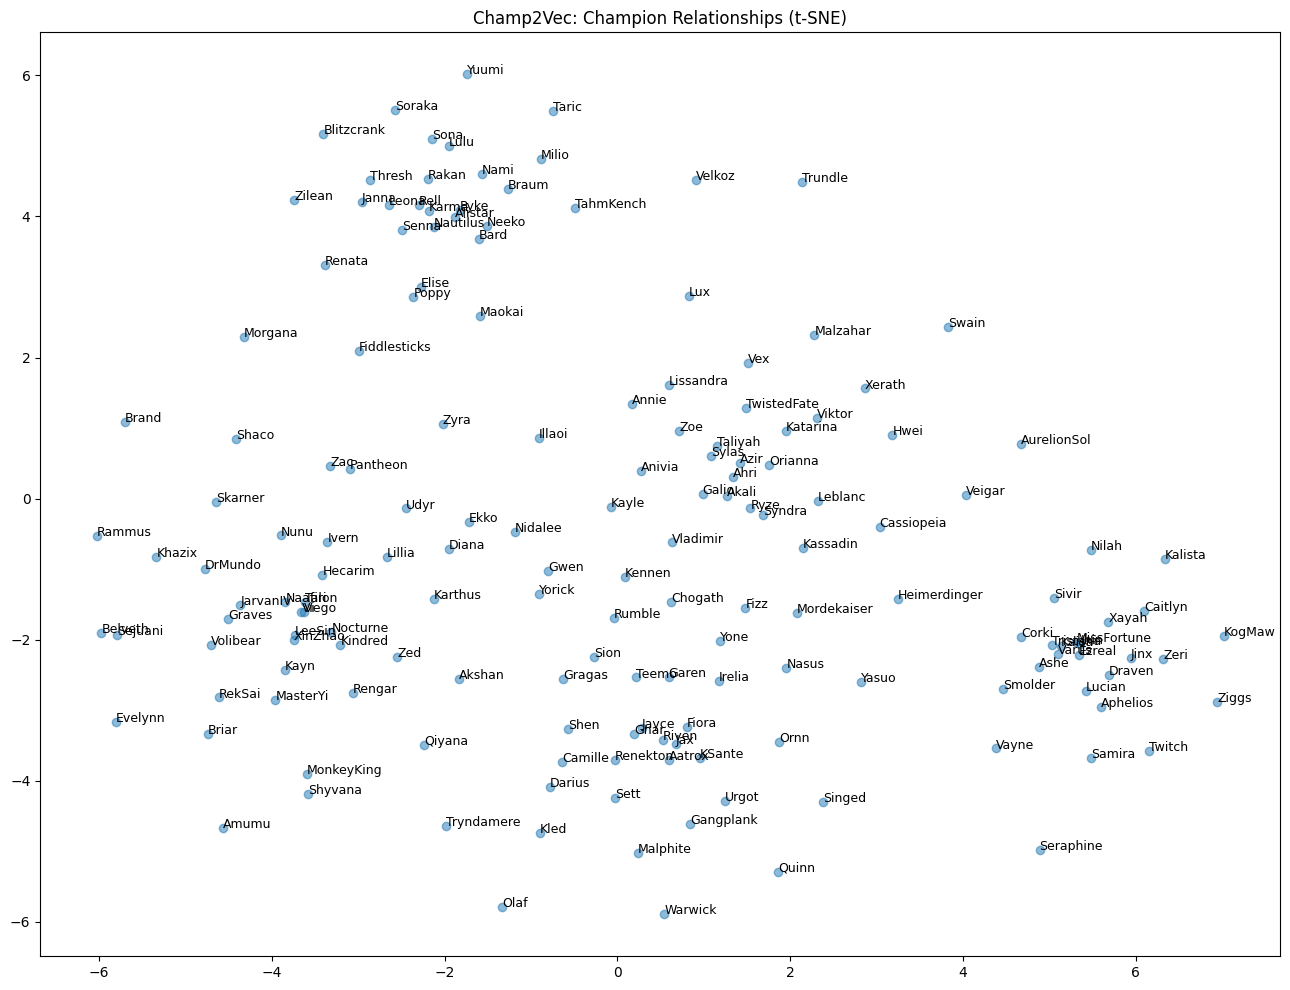

In [40]:
#Plotting the model
embeddings = champ2vec.embedding.weight.detach().cpu().numpy()
#Getting the valid champion embeddings and names
valid_ids = [idx for idx in range(len(embeddings)) if idx in id_to_name]
valid_embeddings = embeddings[valid_ids]
valid_names = [id_to_name[idx] for idx in valid_ids]

#Plotting with t-SNE
tsne = TSNE(n_components=2, perplexity=25, random_state=42)
embeddings_2d = tsne.fit_transform(valid_embeddings)

plt.figure(figsize=(16, 12))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.5)

# 4. Annotate the points with Champion Names
for i, name in enumerate(valid_names):
    plt.annotate(name, (embeddings_2d[i, 0], embeddings_2d[i, 1]), fontsize=9)

plt.title("Champ2Vec: Champion Relationships (t-SNE)")
plt.show()

In [26]:
#Getting data from the csv file
#Getting the dataset from oracle elixir
#df = pd.read_csv("2025_LoL_esports_match_data_from_OraclesElixir.csv")